# IBEX 35 Volatility: Stage 1 — Data & Exploration

This is the first notebook in a project that models IBEX 35 volatility with the
**ARIMA-GARCH** framework, the workhorse approach in market-risk practice for
generating volatility forecasts that feed into Value-at-Risk (VaR) and
Expected Shortfall calculations.

Before fitting any model, we need to establish *why* GARCH-family models are the
right tool. Daily financial returns are not well described by a simple random
walk with constant variance — they exhibit a well-documented set of regularities
known as the **stylized facts of asset returns**: volatility clustering, heavy
tails, and (for squared returns) strong autocorrelation. This notebook downloads
the data and walks through each of these facts empirically, using the IBEX 35 as
the main subject and the S&P 500 as a reference/comparison series.

**Goals of this notebook**
1. Download ~10 years of daily price data for the IBEX 35 (`^IBEX`) and S&P 500 (`^GSPC`).
2. Compute log returns.
3. Visualize and interpret the stylized facts that motivate GARCH modelling.


## 1. Setup

In [1]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf

# We deliberately do not blanket-silence warnings: convergence/numerical
# warnings (e.g. from the arch optimizer in later notebooks, or statsmodels'
# KPSS InterpolationWarning) are informative and should surface. We only
# filter two specific, known-benign, non-substantive messages: a yfinance-
# internal pandas deprecation notice, and a cosmetic statsmodels notice about
# date-index frequency inference that clutters output during model search.
warnings.filterwarnings("ignore", message="Timestamp.utcnow is deprecated.*")
warnings.filterwarnings("ignore", message="A date index has been provided.*")

sys.path.insert(0, "..")
from src.utils import download_data

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100


## 2. Data download

We pull daily closing prices for the IBEX 35 (`^IBEX`) and the S&P 500 (`^GSPC`)
over the last ten years via `yfinance`. The S&P 500 is included as a liquid,
well-studied benchmark to sanity-check that the stylized facts we find in the
IBEX are not a Spanish-market quirk but a generic feature of equity index
returns.

**Reproducibility: this runs from a committed data snapshot, not a live
download.** `download_data()` is cache-first: the fixed 2016-07-01 to
2026-06-30 window used throughout this project is downloaded once and
saved to `data/prices_ibex_sp500.csv`, which is committed to the repo. Every
subsequent call — including this one, and every other notebook's — loads
that file directly and never touches the network. This matters beyond mere
convenience: Yahoo Finance can silently revise historical prices, and two
people running this notebook on different days, or without network access,
would otherwise risk different numbers even with the end date fixed. Pass
`force_download=True` to deliberately refresh the cache from a fresh
download (e.g. if the fixed window is ever moved forward).


In [2]:
prices, log_returns = download_data(pct=False)

prices.tail()


Ticker,SP500,IBEX35
Date,,
2026-06-24,7358.220215,19389.500000
2026-06-25,7357.490234,19513.599609
2026-06-26,7354.020020,19425.300781
2026-06-29,7440.430176,19387.400391
2026-06-30,7499.359863,19471.900391


**A note on price adjustment.** We download data with `auto_adjust=True`, so
the `Close` column `yfinance` returns is already adjusted for splits and
(where applicable) dividends, rather than the raw unadjusted close. This
matters for volatility estimation specifically: an unadjusted series would
show an artificial jump on every ex-dividend date or stock split, which is not
genuine price risk and would inflate measured volatility and contaminate the
GARCH estimates with noise that has nothing to do with market risk.

Separately, ^IBEX and ^GSPC are themselves **price-return indices** — they
track index-level price changes and do not reinvest dividends the way a
total-return index would. That is exactly the right basis for volatility/risk
modelling: what we want to capture is the variability of *prices* (the
quantity that drives mark-to-market P&L and VaR), not the smoother total-return
path that dividend reinvestment would produce.


**Why a ~10-year window?** Ten years gives roughly 2,500 daily observations —
comfortably enough to estimate a GARCH(1,1) model's handful of parameters
precisely. Just as important, it spans genuine stress episodes (the COVID-19
crash in 2020, the 2022 rate-hiking / inflation shock) without which we
wouldn't actually observe volatility clustering — a sample of only calm years
would understate tail risk and give a misleadingly persistent-looking process.
At the same time, we deliberately don't reach further back: much older regimes
(e.g. the 2008 financial crisis, the pre-euro IBEX) had a different volatility
structure and a different index composition, and blending them in would mix
regimes rather than describe the market as it is today. This is the recency
principle common in risk modelling — use enough history to be statistically
robust, not so much that stale regimes dominate the estimate. A natural
robustness check we leave for later is re-running the analysis over 5-, 10-
and 15-year windows to see how sensitive the results are to this choice.


**A note on data quality.** Two points are worth flagging before we go further:

- **Survivorship bias.** Because we work with the *index* series rather than
  its individual constituent stocks, each historical index level already
  reflects whichever companies were actually in the IBEX 35 on that date —
  including firms that later dropped out, were acquired, or went bankrupt. An
  analysis built instead from today's 35 constituents' price histories would
  implicitly survivorship-bias the sample, since it would only include
  companies that "made it" to the present. Using the index sidesteps this.
  Note this is distinct from the return-vs-price choice discussed below —
  that's about stationarity, this is about *which* underlying is being
  measured.
- **Index reconstitution.** The IBEX 35 periodically swaps constituents in and
  out, so "the IBEX" is a renewed portfolio over time rather than a fixed
  basket of 35 companies held for a decade. For our purposes this is a
  feature, not a bug: what we ultimately want to model is the risk of the
  *index concept itself* — the thing ETFs track and the thing that sits on a
  bank's trading book — so any volatility introduced by reconstitution is part
  of what we intend to capture, not noise to be removed.


**A note on trading-day alignment.** The IBEX 35 and S&P 500 don't share an
exchange calendar — each has local holidays the other doesn't (e.g. a Spanish
public holiday when NYSE is open, or vice versa). On those days, `yfinance`
returns a real price for the open market and a missing value for the closed
one. A tempting fix is to forward-fill the gap, but that's wrong for our
purposes: a forward-filled price is identical to the prior day's close, which
manufactures an artificial **zero return** for the closed market on a day
when nothing actually happened to that index — not a real market move, just
a calendar artifact. Padding the sample with fake zero-return days would
quietly understate volatility and distort every stylized fact this notebook
is about to document. We instead keep only days where **both** markets have a
genuine quote (`dropna(how="any")`) — i.e. the two series' *common* trading
days — so every return used from here on reflects an actual price change.


## 3. Log returns

We work with **log returns** rather than simple percentage returns:

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

where $P_t$ is the closing price on day $t$. Two properties make log returns the
standard choice in volatility modelling: they are additive over time (the log
return over $n$ days is the sum of the daily log returns, which simplifies
multi-period variance calculations), and for the small daily price changes
typical of liquid indices they are numerically very close to simple returns,
so no economic intuition is lost.


In [3]:
log_returns.tail()


Ticker,SP500,IBEX35
Date,,
2026-06-24,-0.000983,-0.004477
2026-06-25,-0.000099,0.006380
2026-06-26,-0.000472,-0.004535
2026-06-29,0.011682,-0.001953
2026-06-30,0.007889,0.004349


## 4. Stylized fact #1 — the price series

A quick look at the levels themselves. Prices are non-stationary (they trend and
wander), which is precisely why we model *returns* instead of prices: a
meaningful, stable statistical model needs a series whose mean and variance
don't drift arbitrarily over time.


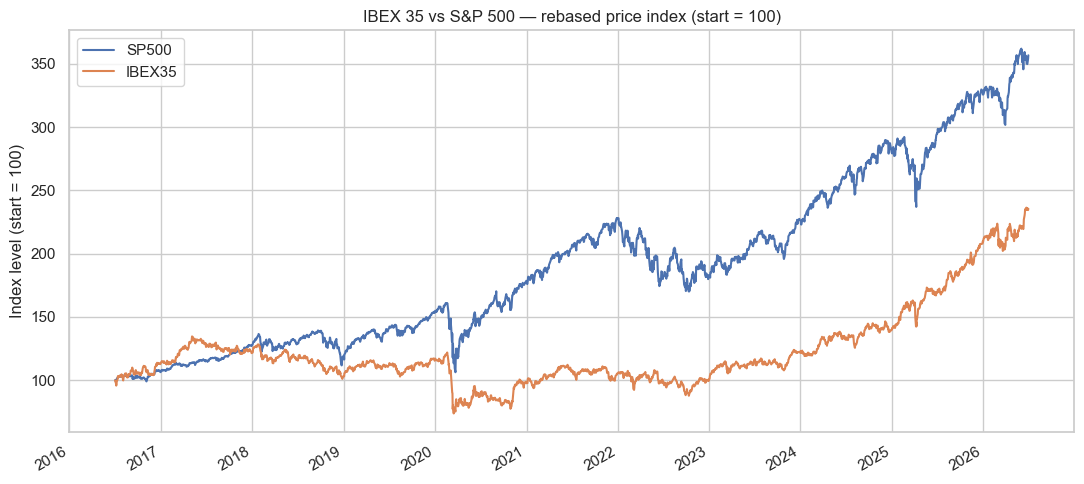

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
(prices / prices.iloc[0] * 100).plot(ax=ax)
ax.set_title("IBEX 35 vs S&P 500 — rebased price index (start = 100)")
ax.set_ylabel("Index level (start = 100)")
ax.set_xlabel("")
ax.legend(title="")
plt.tight_layout()
plt.show()


**Interpretation.** Rebasing both series to 100 at the start of the sample makes
relative performance directly comparable. Beyond whichever index outperformed,
the key thing to notice for our purposes is the *shape* of the path: long
quiet stretches interrupted by sharp drawdowns (COVID-19 in 2020, the 2022
rate-hiking / inflation shock). Those drawdown episodes are exactly where the
next plot — returns rather than levels — becomes interesting: turmoil in prices
shows up as a burst of large-magnitude returns clustered in time.


## 5. Stylized fact #2 — volatility clustering

Plotting the return series itself, rather than prices, reveals the first
stylized fact directly.


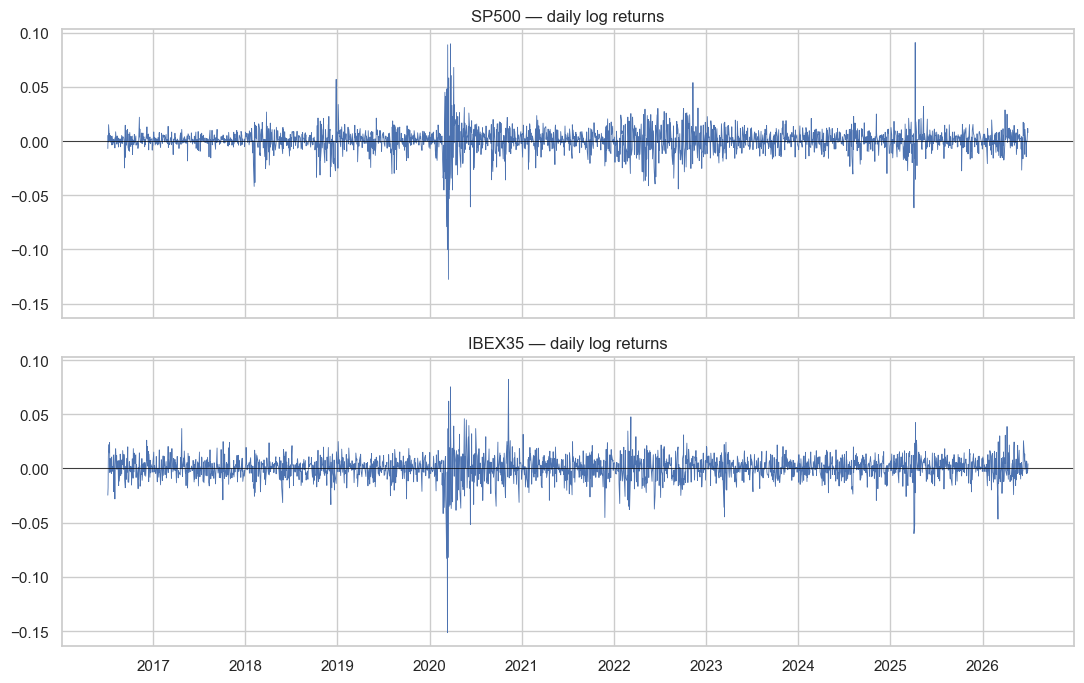

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, sharey=True)
for ax, col in zip(axes, log_returns.columns):
    ax.plot(log_returns.index, log_returns[col], linewidth=0.6)
    ax.set_title(f"{col} — daily log returns")
    ax.axhline(0, color="black", linewidth=0.5)
axes[-1].set_xlabel("")
plt.tight_layout()
plt.show()


**Interpretation.** This is **volatility clustering**: large moves (of either
sign) tend to be followed by more large moves, and calm periods tend to be
followed by more calm periods. Visually, the return series alternates between
low-amplitude "quiet" regimes and high-amplitude "turbulent" regimes, rather
than having uniform amplitude throughout.

This directly contradicts the assumption behind a constant-variance model
(e.g. plain ARIMA on returns, or i.i.d. Gaussian returns): if variance were
constant, large and small moves would be scattered randomly through time, not
grouped together. GARCH models exist specifically to capture this pattern by
letting today's variance depend on recent squared shocks and recent variance —
in other words, by modelling volatility as *itself* being autocorrelated,
even when returns are close to uncorrelated.


## 6. Stylized fact #3 — heavy tails (leptokurtosis)

We compare the empirical return distribution to a normal distribution with the
same mean and standard deviation, and formally test normality with the
**Jarque-Bera** test:

$$
JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right)
$$

where $n$ is the sample size, $S$ is sample skewness, and $K$ is sample
kurtosis. Under the null hypothesis of normality, $JB$ is asymptotically
$\chi^2$-distributed with 2 degrees of freedom. A large $JB$ statistic (small
p-value) rejects normality — and the term $(K-3)^2$ means the test is
particularly sensitive to **excess kurtosis**, i.e. fatter-than-normal tails.


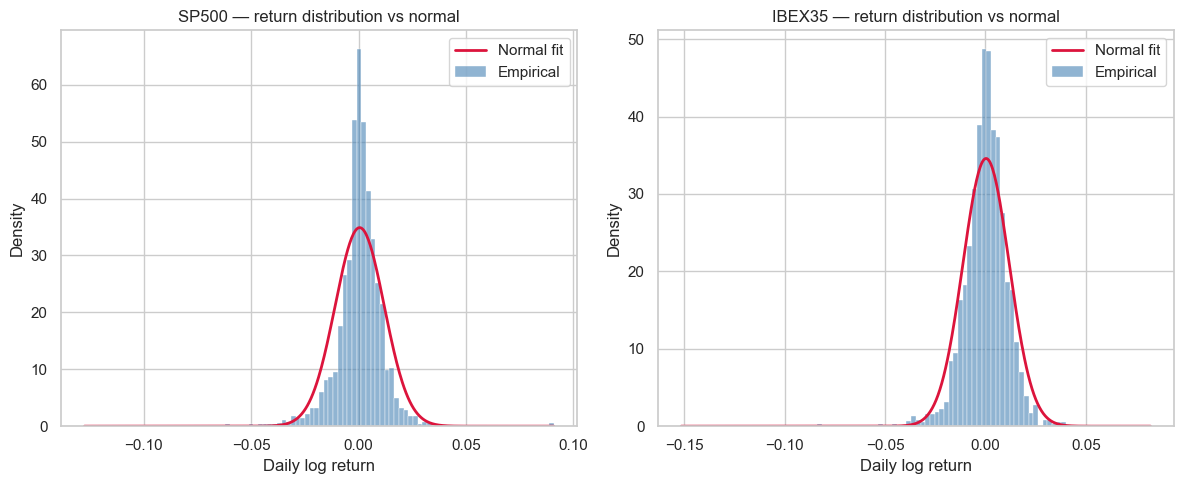

,Skewness,Excess kurtosis,Jarque-Bera stat,JB p-value
Series,,,,
SP500,-0.667363,16.911828,29810.395596,0.0
IBEX35,-1.155336,17.235178,31322.622821,0.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats_table = []
for ax, col in zip(axes, log_returns.columns):
    data = log_returns[col]
    mu, sigma = data.mean(), data.std()

    sns.histplot(data, bins=100, stat="density", ax=ax, color="steelblue", alpha=0.6, label="Empirical")
    x = np.linspace(data.min(), data.max(), 500)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), color="crimson", linewidth=2, label="Normal fit")
    ax.set_title(f"{col} — return distribution vs normal")
    ax.set_xlabel("Daily log return")
    ax.legend()

    jb_stat, jb_pvalue = stats.jarque_bera(data)
    stats_table.append({
        "Series": col,
        "Skewness": stats.skew(data),
        "Excess kurtosis": stats.kurtosis(data),
        "Jarque-Bera stat": jb_stat,
        "JB p-value": jb_pvalue,
    })

plt.tight_layout()
plt.show()

stats_df = pd.DataFrame(stats_table).set_index("Series")
stats_df


**Interpretation.** For a normal distribution, excess kurtosis is 0 (kurtosis
of 3, so $K-3=0$) and skewness is 0. In practice both series show:

- **Excess kurtosis well above 0** — a taller peak around zero and fatter tails
  than the fitted normal curve, visible in the histogram as empirical density
  poking above the red curve near the centre *and* in the extremes, with a
  deficit in between. This means extreme daily moves (large gains or crashes)
  happen far more often than a normal distribution would predict.
- **Negative skewness** — the left tail (large losses) is typically fatter than
  the right tail, consistent with the well-known asymmetry in equity returns
  where crashes are sharper than rallies.
- **A Jarque-Bera p-value effectively at 0** — we reject the null of normality
  at any conventional significance level.

The practical consequence: a risk model that assumes Gaussian returns (e.g. a
naive VaR based on a normal distribution) will systematically **underestimate
the probability of extreme losses**. This is one of the reasons GARCH models
are typically paired with a fat-tailed conditional distribution (Student-t or
skewed-t for the standardized residuals) rather than a normal one.


## 7. Stylized fact #4 — returns are unpredictable, but their *magnitude* isn't

The final and most direct motivation for GARCH: we compare the autocorrelation
function (ACF) of raw returns to the ACF of squared returns. The ACF at lag
$k$, $\rho_k = \text{Corr}(r_t, r_{t-k})$, measures how linearly predictable a
series is from its own past.


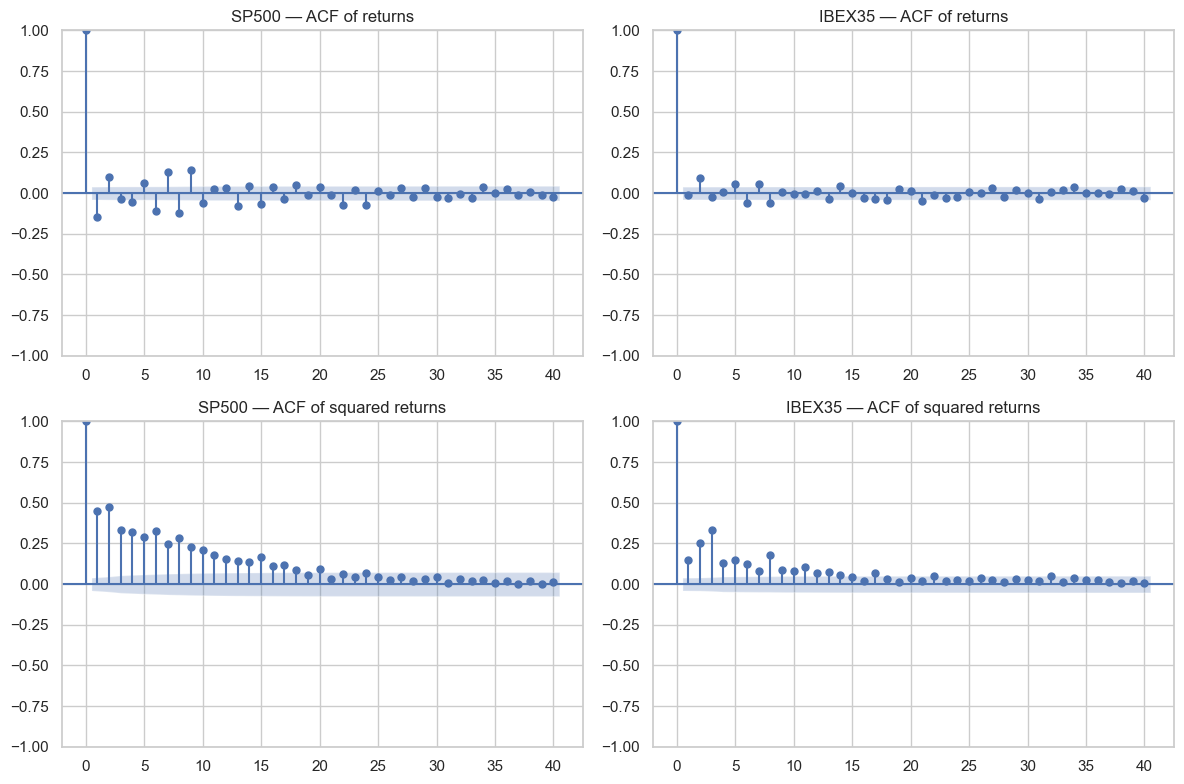

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
lags = 40

for j, col in enumerate(log_returns.columns):
    plot_acf(log_returns[col], lags=lags, ax=axes[0, j], title=f"{col} — ACF of returns")
    plot_acf(log_returns[col] ** 2, lags=lags, ax=axes[1, j], title=f"{col} — ACF of squared returns")

plt.tight_layout()
plt.show()


**Interpretation.** The two rows tell contrasting stories:

- **ACF of raw returns (top row):** autocorrelations sit close to zero and
  mostly inside the significance band (shaded blue) at almost every lag. This
  is consistent with markets being close to informationally efficient at the
  daily horizon — you cannot predict tomorrow's *sign or direction* from
  today's return in any simple linear way.
- **ACF of squared returns (bottom row):** autocorrelations are strongly
  positive and decay slowly over many lags, clearly outside the significance
  band. Since squared returns are a proxy for realized variance, this says
  today's volatility is highly informative about tomorrow's volatility, even
  though today's *return* tells us almost nothing about tomorrow's *return*.

This pair of plots is the empirical fingerprint that GARCH models are built to
match: **returns near-unpredictable in the mean, but volatility highly
predictable and persistent**. A GARCH(1,1) model captures this by writing
conditional variance as an autoregressive process in past squared shocks and
past variance:

$$
\sigma_t^2 = \omega + \alpha\,\varepsilon_{t-1}^2 + \beta\,\sigma_{t-1}^2
$$

- $\sigma_t^2$: the conditional variance (volatility squared) forecast for day $t$.
- $\omega > 0$: a baseline/long-run variance level.
- $\varepsilon_{t-1}^2$: yesterday's squared shock (return surprise) — the
  "news" or ARCH term, with weight $\alpha$.
- $\sigma_{t-1}^2$: yesterday's conditional variance — the persistence or
  "memory" term, with weight $\beta$.

The slow-decaying ACF of squared returns we just plotted is direct empirical
evidence that $\beta$ (persistence) will need to be large for a GARCH(1,1) fit
on this data — a point we'll verify quantitatively when we estimate the model
in the next notebook.


## 8. Summary

The IBEX 35 (and, for comparison, the S&P 500) daily log returns display the
classic stylized facts of financial time series:

1. **Prices are non-stationary**, which is why we model returns instead.
2. **Volatility clustering** — turbulent and calm periods come in clusters, so
   variance is not constant over time.
3. **Heavy tails** — the empirical distribution has significantly more mass in
   the extremes than a normal distribution, confirmed by a Jarque-Bera test
   that firmly rejects normality.
4. **Near-zero return autocorrelation but strong, persistent squared-return
   autocorrelation** — the direct empirical signature that motivates an
   ARCH/GARCH specification for the conditional variance.

**Next stage:** fit an ARIMA model to the conditional mean (if any structure
remains) and a GARCH model to the residual variance, then validate with
Ljung-Box tests on standardized residuals and squared standardized residuals.


**Scope note:** this project's limitations (horizon, univariate scope,
distributional assumptions, tail-risk modelling, window length, backtest
refit cadence, transaction costs) are collected in one place at the end of
Stage 5, Section 12 ("Limitations and scope").
